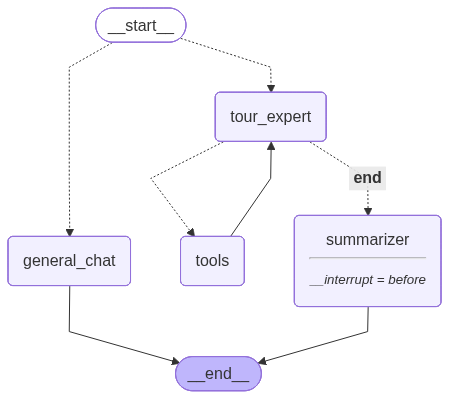

In [3]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver

# ==========================================
# 1. 멀티 도구(Tools) 만들기 & 디스크립션 깎기
# ==========================================
@tool
def get_weather(location: str) -> str:
    """특정 지역의 날씨를 검색하는 도구입니다. 
    사용자가 여행이나 외출을 위해 날씨, 온도, 비가 오는지 등을 물어볼 때 반드시 사용하세요."""
    return f"{location}의 오늘 날씨는 맑음입니다."

@tool
def search_restaurants(location: str, food_type: str) -> str:
    """특정 지역의 맛집을 검색하는 도구입니다.
    사용자가 식당, 밥집, 맛집 추천을 요구할 때 장소와 음식 종류를 넣어 사용하세요."""
    return f"{location} 추천 {food_type} 맛집: '치이네 오므라이스' (별점 5점)"

@tool
def calculate_budget(prices: list[int]) -> str:
    """예산을 계산하는 계산기 도구입니다.
    식비나 여행 경비의 총합을 구할 때 숫자들의 리스트를 넣어 사용하세요."""
    return f"총 예상 비용은 {sum(prices)}원입니다."

# 도구를 리스트로 묶기
tools = [get_weather, search_restaurants, calculate_budget]

# ==========================================
# 2. 커스텀 State 정의
# ==========================================
class TourState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    # 요약본을 담을 커스텀 필드 추가!
    summary: str 

# ==========================================
# 3. 노드(Node) 만들기
# ==========================================
def router_node(state: TourState) -> Literal["general_chat", "tour_expert"]:
    """질문을 보고 일반 대화인지, 검색인지 길을 나누는 라우터"""
    last_msg = state["messages"][-1].content
    if "안녕" in last_msg or "반가워" in last_msg:
        return "general_chat"
    return "tour_expert"

def general_chat(state: TourState):
    """도구 없이 가볍게 수다 떠는 노드"""
    return {"messages": [AIMessage(content="안녕하세요! 천재 메이드 치이예요. 맛집이나 날씨를 물어보세요!")]}

def tour_expert(state: TourState):
    """도구를 장착한 진짜 전문가 챗봇 노드 (여기에 LLM invoke 로직이 들어가겠지?)"""
    pass

def summarizer_node(state: TourState):
    """검색이 다 끝나고 결과를 예쁘게 포장해주는 요약 노드"""
    last_message = state["messages"][-1].content
    final_reply = f"✨ [치이의 맛집 요약 보고서] ✨\n{last_message}\n\n주인님, 맛있게 드시고 오세요! 에헤헷♥"
    # 기존 메시지는 두고, 요약본을 마지막 답변으로 덮어치기!
    return {"messages": [AIMessage(content=final_reply)]}

# ==========================================
# 4. 나만의 랭그래프 조립하기 (자유로운 프로세스!)
# ==========================================
builder = StateGraph(TourState)

# 노드 등록
builder.add_node("general_chat", general_chat)
builder.add_node("tour_expert", tour_expert)
builder.add_node("tools", ToolNode(tools))
builder.add_node("summarizer", summarizer_node)

# 라우터로 시작 길 나누기
builder.add_conditional_edges(START, router_node)
builder.add_edge("general_chat", END)

# 툴을 쓸지 말지 결정 (도구가 필요하면 tools로, 끝나면 END가 아니라 summarizer로 가도록 맵핑!)
builder.add_conditional_edges(
    "tour_expert", 
    tools_condition,
    {"tools": "tools", "__end__": "summarizer"}  # 요기가 핵심 포인트!
)
builder.add_edge("tools", "tour_expert")
builder.add_edge("summarizer", END)

# 짠! 나만의 멋진 랭그래프 완성!
# graph = builder.compile()

graph = builder.compile(
    checkpointer=MemorySaver(),
    interrupt_before=["summarizer"]
)


graph
